In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
#models
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import warnings

In [64]:
df = pd.read_csv(r'D:\projects\mlproject1\Notebook\data\StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [65]:
X = df.drop(columns=['math score'], axis=1)
y = df['math score']

In [66]:
num_features =[feat for feat in X.columns if X[feat].dtype !='O']
cat_features = [feat for feat in X.columns if X[feat].dtype == 'O']


In [67]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


In [68]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 7), (200, 7), (800,), (200,))

In [70]:
x_train_transformed = preprocessor.fit_transform(X_train)
x_test_transformed = preprocessor.transform(X_test)
x_train_transformed.shape, x_test_transformed.shape

((800, 19), (200, 19))

In [71]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [72]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN Regressor': KNeighborsRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=0),
    'Decision Tree Regressor': DecisionTreeRegressor()}

model_list = []
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train_transformed, y_train)

    y_train_pred = model.predict(x_train_transformed)
    y_test_pred = model.predict(x_test_transformed)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    r2_list.append(test_r2)





    print("train mae: {:,.2f}".format(train_mae))
    print(f'Train MSE: {train_mse}')
    print(f'Train RMSE: {train_rmse}')
    print(f'Train R2 Score: {train_r2}')  

    print("---------------------------------------")
    print(f'Test MAE: {test_mae}')
    print(f'Test MSE: {test_mse}')
    print(f'Test RMSE: {test_rmse}')
    print(f'Test R2 Score: {test_r2}')
    
    print('='*50)
    print('\n')


Linear Regression
train mae: 4.27
Train MSE: 28.33487038064859
Train RMSE: 5.323050852720514
Train R2 Score: 0.8743172040139593
---------------------------------------
Test MAE: 4.21476314247485
Test MSE: 29.095169866715477
Test RMSE: 5.393993869732841
Test R2 Score: 0.8804332983749565


Ridge Regression
train mae: 4.27
Train MSE: 28.337741791088877
Train RMSE: 5.323320560617112
Train R2 Score: 0.8743044675204547
---------------------------------------
Test MAE: 4.211112826071164
Test MSE: 29.056601626694828
Test RMSE: 5.390417574427312
Test R2 Score: 0.8805917946912825


Lasso Regression
train mae: 5.21
Train MSE: 43.46106018771194
Train RMSE: 6.592500298650879
Train R2 Score: 0.8072231322208645
---------------------------------------
Test MAE: 5.155701094273798
Test MSE: 42.47556715227398
Test RMSE: 6.517328221922997
Test R2 Score: 0.8254465092551198


KNN Regressor
train mae: 4.51
Train MSE: 32.48015
Train RMSE: 5.699135899414928
Train R2 Score: 0.855930307384291
-------------------

In [73]:
pd.DataFrame({'Model': model_list, 'R2 Score': r2_list}).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
1,Ridge Regression,0.880592
0,Linear Regression,0.880433
5,Gradient Boosting Regressor,0.872347
4,Random Forest Regressor,0.853261
8,CatBoost Regressor,0.851831
6,AdaBoost Regressor,0.844676
2,Lasso Regression,0.825447
7,XGBoost Regressor,0.821220
3,KNN Regressor,0.783958
9,Decision Tree Regressor,0.756265


In [74]:
model = Ridge()
model.fit(x_train_transformed, y_train)
y_pred = model.predict(x_test_transformed)
y_pred.shape

(200,)

In [75]:
pd.DataFrame({'actual': y_test, 'predicted': y_pred, 'residual': y_test - y_pred})

,actual,predicted,residual
521,91,76.398746,14.601254
737,53,58.843165,-5.843165
740,80,76.992035,3.007965
660,74,76.806200,-2.806200
411,84,87.614981,-3.614981
...,...,...,...
408,52,43.491767,8.508233
332,62,62.170101,-0.170101
208,74,67.910260,6.089740
613,65,67.061256,-2.061256


<Axes: xlabel='math score'>

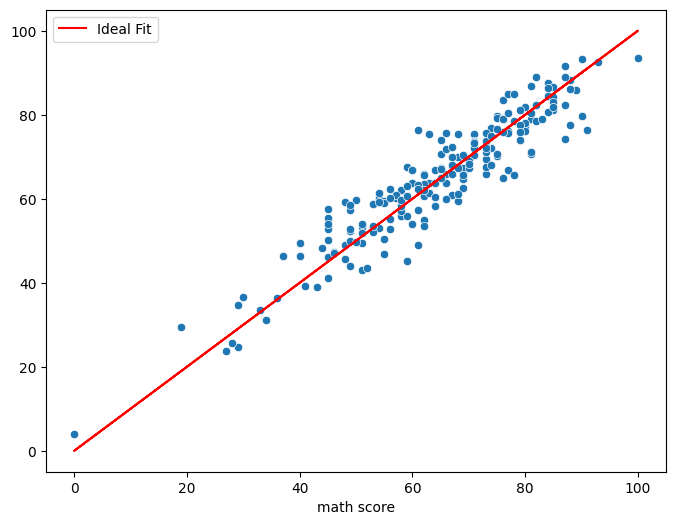

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(y_test, y_test, color='red', label='Ideal Fit') 
sns.scatterplot(x=y_test, y=y_pred)
sns.p